# Experiment 2 · Hidden-Layer Perceptron

Experiment 1 showed that a single sigmoid node cannot learn XOR: it can only draw one
straight decision line, and XOR needs two. This experiment adds a hidden layer —
`2 inputs -> 4 hidden (sigmoid) -> 1 output (sigmoid)` — and shows that this
extra layer is enough for the network to learn XOR.

In [1]:
import sys
from pathlib import Path

# the repository root is the first folder above this notebook that holds pyproject.toml
REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np

from numpy_nn import ACTIVATIONS, COSTS, Layer, Network, random_weights, zero_bias
from numpy_trainer import DataLoader, Trainer, plot_decision_boundary, plot_history, print_predictions

LEARNING_RATE = 0.7
EPOCHS = 5000

XOR_INPUTS = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
XOR_TARGETS = np.array([[0], [1], [1], [0]], dtype=float)

def report(network, inputs, targets):
    for index, layer in enumerate(network.layers):
        print(f"layer {index} weights: {np.round(layer.weights, 4).tolist()}")
        print(f"layer {index} bias:    {np.round(layer.bias, 4).tolist()}")
    print()
    print_predictions(inputs, targets, network.forward(inputs))

## Building a hidden-layer network

The hidden layer's 4 nodes each draw their own line through the input
space; the output node then combines those 4 lines into a single non-linear
boundary — enough to separate `{(0,1), (1,0)}` from `{(0,0), (1,1)}`.

The deeper network starts on a long plateau before it finds that boundary, so it is
trained for 5000 epochs instead of Experiment 1's 500.

In [2]:
np.random.seed(1)

hidden_layer = Layer.build(
    input_size=2, output_size=4,
    weight=random_weights(input_size=2, output_size=4), bias=zero_bias(4),
    activation=ACTIVATIONS.SIGMOID,
)
output_layer = Layer.build(
    input_size=4, output_size=1,
    weight=random_weights(input_size=4, output_size=1), bias=zero_bias(1),
    activation=ACTIVATIONS.SIGMOID,
)
xor_network = Network(hidden_layer, output_layer)

xor_trainer = Trainer(xor_network, cost=COSTS.MSE, learning_rate=LEARNING_RATE)
xor_trainer.train(
    DataLoader(XOR_INPUTS, XOR_TARGETS, batch_size=1, shuffle=False),
    epochs=EPOCHS,
    print_interval=500,
);

epoch  500 | loss: 0.0068 | accuracy: 100.00%
epoch 1000 | loss: 0.0016 | accuracy: 100.00%
epoch 1500 | loss: 0.0009 | accuracy: 100.00%


epoch 2000 | loss: 0.0006 | accuracy: 100.00%
epoch 2500 | loss: 0.0005 | accuracy: 100.00%
epoch 3000 | loss: 0.0004 | accuracy: 100.00%


epoch 3500 | loss: 0.0003 | accuracy: 100.00%
epoch 4000 | loss: 0.0003 | accuracy: 100.00%
epoch 4500 | loss: 0.0002 | accuracy: 100.00%


epoch 5000 | loss: 0.0002 | accuracy: 100.00%


In [3]:
report(xor_network, XOR_INPUTS, XOR_TARGETS)

layer 0 weights: [[-1.4238, -1.4611], [-1.0222, -0.8331], [-6.7137, -6.7022], [-4.7787, -4.7782]]
layer 0 bias:    [1.7288, -0.0894, 2.775, 7.1009]
layer 1 weights: [[2.0407, 0.5927, -11.0243, 9.3901]]
layer 1 bias:    [-5.3715]

inputs: [0.0000, 0.0000] | target: [0.0000] | prediction: [0.0127]
inputs: [0.0000, 1.0000] | target: [1.0000] | prediction: [0.9865]
inputs: [1.0000, 0.0000] | target: [1.0000] | prediction: [0.9865]
inputs: [1.0000, 1.0000] | target: [0.0000] | prediction: [0.0168]


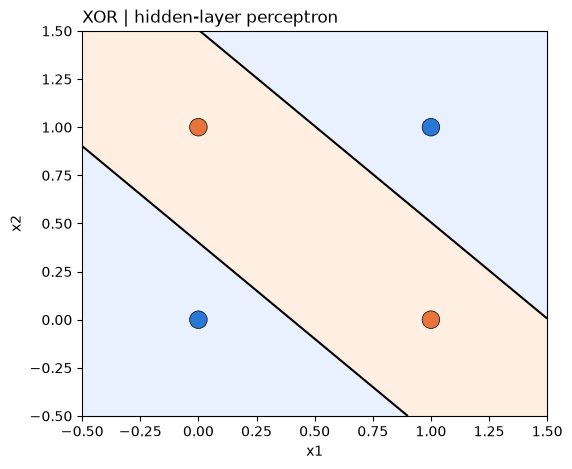

In [4]:
plot_decision_boundary(xor_network, XOR_INPUTS, XOR_TARGETS, title="XOR | hidden-layer perceptron");

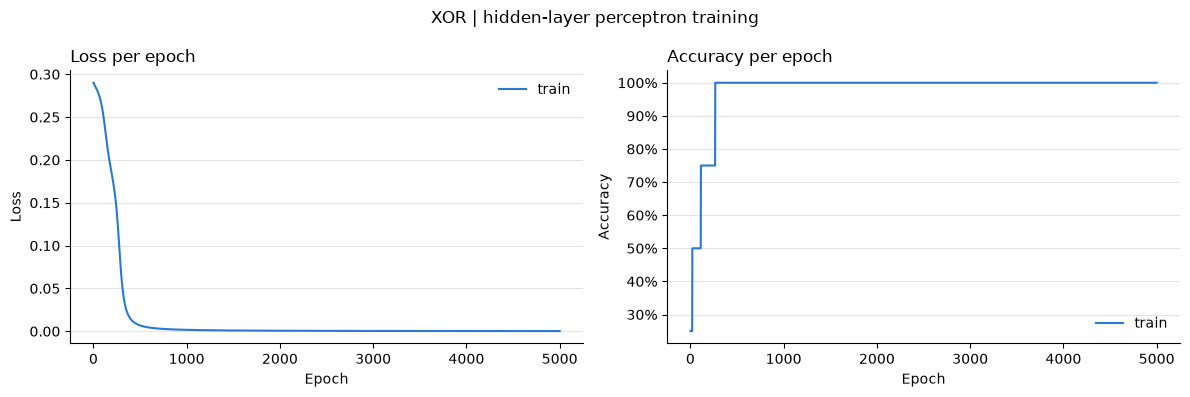

In [5]:
plot_history(xor_trainer.history, title="XOR | hidden-layer perceptron training")

## Takeaway

With a hidden layer the decision region is no longer a half-plane: the network carves out a
band that holds `(0,1)` and `(1,0)` and leaves `(0,0)` and `(1,1)` outside, and all four points
are classified correctly. The loss curve shows the typical XOR shape: a slow start while the
hidden units are still nearly interchangeable, then a sharp drop around epochs 200–400 once they
specialise. Accuracy reaches 100% before epoch 300; the remaining epochs only push the outputs
closer to 0 and 1.